In [1]:
import pickle
import numpy as np
import pandas as pd

import scanpy as sc
import anndata
import random

import torch
from torch import nn
from torch import optim
from torch.nn import functional as F

import os
import matplotlib.pyplot as plt

from matplotlib.patches import Patch
from seaborn import heatmap, lineplot, clustermap
import seaborn as sns
from sklearn.metrics import adjusted_rand_score

from contrastive_NMF import nmf_sse
from contrastive_NMF import nmf_poisson
from contrastive_NMF import nmf_poisson_minibatch
from contrastive_NMF import contrastive_nmf_sse
from contrastive_NMF import contrastive_nmf_poisson
from contrastive_NMF import contrastive_nmf_poisson_minibatch
#import igraph as ig
#import louvain as lv
print("MPS Available:", torch.backends.mps.is_available())
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
random.seed(10)

MPS Available: True


## Data Preprocess

In [2]:
import numpy as np
%matplotlib inline

data = np.genfromtxt('datasets/Data_Cortex_Nuclear.csv',delimiter=',',
                     skip_header=1,usecols=range(1,78),filling_values=0)
classes = np.genfromtxt('datasets/Data_Cortex_Nuclear.csv',delimiter=',',
                        skip_header=1,usecols=range(78,81),dtype=None)

In [3]:
target_idx_A = np.where((classes[:,-1]=='S/C') & (classes[:,-2]=='Saline') & (classes[:,-3]=='Control'))[0]
target_idx_B = np.where((classes[:,-1]=='S/C') & (classes[:,-2]=='Saline') & (classes[:,-3]=='Ts65Dn'))[0]

labels = len(target_idx_A)*[0] + len(target_idx_B)*[1]
target_idx = np.concatenate((target_idx_A,target_idx_B))                                                                          

target = data[target_idx]

background_idx = np.where((classes[:,-1]=='C/S') & (classes[:,-2]=='Saline') & (classes[:,-3]=='Control'))
background = data[background_idx]

## bcNMF

In [4]:
X = target  # Target dataset
Y = background  # Background dataset
# Define parameters for NMF
K = 5  # Number of latent components
alpha = 3 # Specific alpha value
niter = 100  # Number of iterations for NMF

# Run Contrastive NMF for the specific alpha value
W_nmf_sse, H_X_nmf_sse, H_Y_nmf_sse, nmf_sse_perf = contrastive_nmf_sse(X.T, Y.T, K, alpha, niter=niter)

Iter: 0 .. MSE: 3.6495
Iter: 1 .. MSE: 4.0525
Iter: 2 .. MSE: 4.2199
Iter: 3 .. MSE: 4.2950
Iter: 4 .. MSE: 4.3390
Iter: 5 .. MSE: 4.3650
Iter: 6 .. MSE: 4.3776
Iter: 7 .. MSE: 4.3799
Iter: 8 .. MSE: 4.3741
Iter: 9 .. MSE: 4.3622
Iter: 10 .. MSE: 4.3462
Iter: 11 .. MSE: 4.3273
Iter: 12 .. MSE: 4.3061
Iter: 13 .. MSE: 4.2829
Iter: 14 .. MSE: 4.2579
Iter: 15 .. MSE: 4.2320
Iter: 16 .. MSE: 4.2065
Iter: 17 .. MSE: 4.1826
Iter: 18 .. MSE: 4.1606
Iter: 19 .. MSE: 4.1398
Iter: 20 .. MSE: 4.1195
Iter: 21 .. MSE: 4.1002
Iter: 22 .. MSE: 4.0823
Iter: 23 .. MSE: 4.0656
Iter: 24 .. MSE: 4.0495
Iter: 25 .. MSE: 4.0346
Iter: 26 .. MSE: 4.0238
Iter: 27 .. MSE: 4.0194
Iter: 28 .. MSE: 4.0193
Iter: 29 .. MSE: 4.0187
Iter: 30 .. MSE: 4.0145
Iter: 31 .. MSE: 4.0075
Iter: 32 .. MSE: 4.0005
Iter: 33 .. MSE: 3.9956
Iter: 34 .. MSE: 3.9930
Iter: 35 .. MSE: 3.9899
Iter: 36 .. MSE: 3.9834
Iter: 37 .. MSE: 3.9727
Iter: 38 .. MSE: 3.9612
Iter: 39 .. MSE: 3.9543
Iter: 40 .. MSE: 3.9547
Iter: 41 .. MSE: 3.9609
It

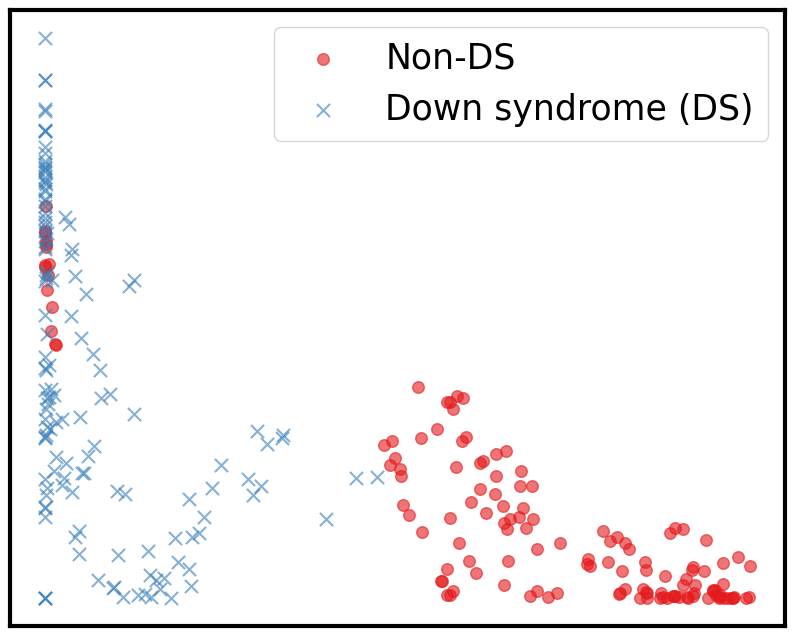

In [119]:
# Calculate the variance of each row in H_X_nmf_sse
row_variances = np.var(H_X_nmf_sse, axis=1)

# Select the indices of the two rows with the largest variance
top_two_indices = np.argsort(row_variances)[-2:]  # Get the indices of the top 2 rows with highest variance

# Use these rows for visualization
reduced_X = H_X_nmf_sse[top_two_indices, :].T  # Take the selected rows and transpose for plotting

# Scatter plot for the target dataset using rows with largest variance
class_0_idx = np.where(np.array(labels) == 0)[0]  # Class 0 (Jogging)
class_1_idx = np.where(np.array(labels) == 1)[0]  # Class 1 (Squatting)
colors = ["#E41A1C", "#377EB8"] 

fig, ax = plt.subplots(figsize=(10, 8))
plt.scatter(reduced_X[class_0_idx, 0], reduced_X[class_0_idx, 1], color=colors[0], alpha=0.6, marker='o', label="Non-DS", s=70)
plt.scatter(reduced_X[class_1_idx, 0], reduced_X[class_1_idx, 1], color=colors[1], alpha=0.6, marker='x',label="Down syndrome (DS)", s=90)

# Add titles and labels
#plt.title(f"bcNMF Scatter Plot for Mice protein expression", fontsize=16)

legend = ax.legend(loc='best', fontsize=25)
plt.xticks([])
plt.yticks([])
for spine in ['top', 'bottom', 'left', 'right']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_edgecolor('black')
    ax.spines[spine].set_linewidth(3)
plt.show()

In [ ]:
np.save('W_nmf_sse_mice_protein.npy', W_nmf_sse)
np.save('H_X_nmf_sse_mice_protein.npy', H_X_nmf_sse)
np.save('H_Y_nmf_sse_mice_protein.npy', H_Y_nmf_sse)

In [5]:
W_nmf_sse = np.load('W_nmf_sse_mice_protein.npy')
H_X_nmf_sse = np.load('H_X_nmf_sse_mice_protein.npy')
H_Y_nmf_sse = np.load('H_Y_nmf_sse_mice_protein.npy')

In [17]:
import umap
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans
umap_reducer = umap.UMAP(n_components=2, random_state=42)
H_umap = umap_reducer.fit_transform(H_X_nmf_sse.T)

# Extract metadata


# Get labels
conditions = labels

# Calculate ARI for conditions
unique_conditions = np.unique(conditions)
condition_map = {cond: i for i, cond in enumerate(unique_conditions)}
condition_numeric = np.array([condition_map[c] for c in conditions])

kmeans_cond = KMeans(n_clusters=len(unique_conditions), random_state=42)
pred_cond = kmeans_cond.fit_predict(H_umap)
ari_condition = adjusted_rand_score(condition_numeric, pred_cond)

print(f"ARI for TP53 mutation status: {ari_condition:.3f}")

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


ARI for TP53 mutation status: 0.651


In [6]:
data_raw = np.genfromtxt('datasets/Data_Cortex_Nuclear.csv', delimiter=',', 
                         names=True, dtype=None, encoding=None)
protein_names = data_raw.dtype.names[1:78]

In [7]:
def get_regression_pvalue_robust(factor_values, conditions):
    """
    Perform robust linear regression using statsmodels
    Returns p-value and statistics
    """
    # Create design matrix with intercept
    X = sm.add_constant(conditions)
    y = factor_values
    
    try:
        # Fit OLS model
        model = sm.OLS(y, X).fit()
        # Get p-value for the condition coefficient (not intercept)
        p_value = model.pvalues[1]
        coef = model.params[1]
        t_stat = model.tvalues[1]
        
        # If p-value is extremely small, use t-test as backup
        if p_value < 1e-300:
            # Perform t-test
            control_vals = factor_values[conditions == 0]
            case_vals = factor_values[conditions == 1]
            t_stat_backup, p_value_backup = ttest_ind(control_vals, case_vals)
            p_value = p_value_backup
            
    except Exception as e:
        # Fallback to t-test
        control_vals = factor_values[conditions == 0]
        case_vals = factor_values[conditions == 1]
        t_stat, p_value = ttest_ind(control_vals, case_vals)
        coef = np.mean(case_vals) - np.mean(control_vals)
        
    # Ensure p-value is not exactly 0
    p_value = max(p_value, np.finfo(float).eps)
    
    return p_value, coef, t_stat

# Alternative: Use simple t-test for more stable p-values
def get_ttest_pvalue(factor_values, conditions):
    """
    Perform two-sample t-test
    """
    control_vals = factor_values[conditions == 0]
    ds_vals = factor_values[conditions == 1]
    
    # Check for variance
    if np.var(control_vals) == 0 and np.var(ds_vals) == 0:
        if np.mean(control_vals) == np.mean(ds_vals):
            return 1.0, 0.0
        else:
            return 1e-10, np.mean(ds_vals) - np.mean(control_vals)
    
    # Perform t-test (Welch's t-test for unequal variances)
    t_stat, p_value = ttest_ind(control_vals, ds_vals, equal_var=False)
    
    # Ensure p-value is valid
    if np.isnan(p_value):
        p_value = 1.0
    
    # Prevent exact 0
    p_value = max(p_value, np.finfo(float).eps)
    
    effect_size = np.mean(ds_vals) - np.mean(control_vals)
    
    return p_value, effect_size

# Calculate p-values for ALL components
H_transposed = H_X_nmf_sse.T  # Shape: (n_samples, n_components)
n_components = H_transposed.shape[1]
conditions = np.array(labels)

print("Calculating p-values for all components...")
print(f"Sample sizes: Control={sum(conditions==0)}, DS={sum(conditions==1)}")

results_all = []
for i in range(n_components):
    factor_values = H_transposed[:, i]
    
    # Use t-test for more stable p-values
    p_value, effect_size = get_ttest_pvalue(factor_values, conditions)
    
    # Calculate additional statistics
    control_vals = factor_values[conditions == 0]
    ds_vals = factor_values[conditions == 1]
    
    # Cohen's d for effect size
    pooled_std = np.sqrt(((len(control_vals)-1)*np.var(control_vals) + 
                          (len(ds_vals)-1)*np.var(ds_vals)) / 
                         (len(control_vals) + len(ds_vals) - 2))
    if pooled_std > 0:
        cohens_d = effect_size / pooled_std
    else:
        cohens_d = 0
    
    results_all.append({
        'Component': f'Component_{i+1}',
        'Component_idx': i,
        'P_value': p_value,
        'Log10_pvalue': -np.log10(max(p_value, 1e-300)),
        'Effect_size': effect_size,
        'Cohens_d': cohens_d,
        'Control_mean': np.mean(control_vals),
        'Control_std': np.std(control_vals),
        'DS_mean': np.mean(ds_vals),
        'DS_std': np.std(ds_vals),
        'Is_significant': p_value < 0.05
    })

results_df = pd.DataFrame(results_all)

# Sort by p-value and get top 2
results_df_sorted = results_df.sort_values('P_value')
top2_components = results_df_sorted.head(2)

print("\n" + "="*70)
print("COMPONENT STATISTICS:")
print("="*70)
print("Component | P-value    | Effect | Cohen's d | Control Mean±SD | DS Mean±SD")
print("-"*70)
for _, row in results_df_sorted.head(5).iterrows():
    print(f"{row['Component']:12} | {row['P_value']:.2e} | {row['Effect_size']:7.4f} | {row['Cohens_d']:9.3f} | "
          f"{row['Control_mean']:.4f}±{row['Control_std']:.4f} | {row['DS_mean']:.4f}±{row['DS_std']:.4f}")

print("\n" + "="*70)
print("TOP 2 MOST SIGNIFICANT COMPONENTS:")
print("="*70)
for _, row in top2_components.iterrows():
    print(f"\n{row['Component']}:")
    print(f"  P-value: {row['P_value']:.6e}")
    print(f"  Effect size: {row['Effect_size']:.6f}")
    print(f"  Cohen's d: {row['Cohens_d']:.3f}")
    print(f"  Control: {row['Control_mean']:.6f} ± {row['Control_std']:.6f}")
    print(f"  DS: {row['DS_mean']:.6f} ± {row['DS_std']:.6f}")

# Get indices of top 2 components
top2_idx = top2_components['Component_idx'].values
top2_labels = top2_components['Component'].values

Calculating p-values for all components...
Sample sizes: Control=135, DS=135


NameError: name 'ttest_ind' is not defined

In [8]:
# Extract the W matrix for top 2 components
W_top2 = W_nmf_sse[:, top2_idx]  # Shape: (n_proteins, 2)

# Get top 10 proteins for EACH component
protein_rows = []
protein_indices = []
topN = 10

print("\n" + "="*70)
print("TOP PROTEINS PER COMPONENT:")
print("="*70)

for comp_idx, comp_label in zip(top2_idx, top2_labels):
    # Get top 10 proteins for this component
    component_weights = W_nmf_sse[:, comp_idx]
    top10_idx = np.argsort(component_weights)[-topN:][::-1]
    
    print(f"\nTop {topN} proteins for {comp_label}:")
    for rank, idx in enumerate(top10_idx, 1):
        print(f"  {rank:2d}. {protein_names[idx]:15s}: {component_weights[idx]:.6f}")
        protein_rows.append(protein_names[idx])
        protein_indices.append(idx)

# Create heatmap matrix with ACTUAL values
heatmap_matrix = []
for protein_idx in protein_indices:
    # Get the actual NMF loading values for this protein across BOTH top components
    vals = W_nmf_sse[protein_idx, top2_idx]
    heatmap_matrix.append(vals)

heat_df = pd.DataFrame(heatmap_matrix, 
                       index=protein_rows, 
                       columns=[f'Comp_{i+1}' for i in top2_idx])

NameError: name 'top2_idx' is not defined

In [125]:
print("\n" + "="*70)
print("CALCULATING PROTEIN P-VALUES:")
print("="*70)

protein_pvalues = []
protein_stats = []

for i, protein_idx in enumerate(protein_indices):
    protein_values = target[:, protein_idx]
    
    # T-test
    p_val, effect = get_ttest_pvalue(protein_values, conditions)
    protein_pvalues.append(p_val)
    protein_stats.append({
        'protein': protein_rows[i],
        'p_value': p_val,
        'effect': effect
    })

# Print summary
significant_proteins = sum(p < 0.05 for p in protein_pvalues)
print(f"Total proteins: {len(protein_pvalues)}")
print(f"Significant (p<0.05): {significant_proteins}")
print(f"P-value range: {min(protein_pvalues):.2e} to {max(protein_pvalues):.2e}")


CALCULATING PROTEIN P-VALUES:
Total proteins: 20
Significant (p<0.05): 18
P-value range: 2.22e-16 to 6.38e-01


/var/folders/v5/x07md57n5fn41s9ln1bztt9w0000gn/T/ipykernel_65411/1866870821.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


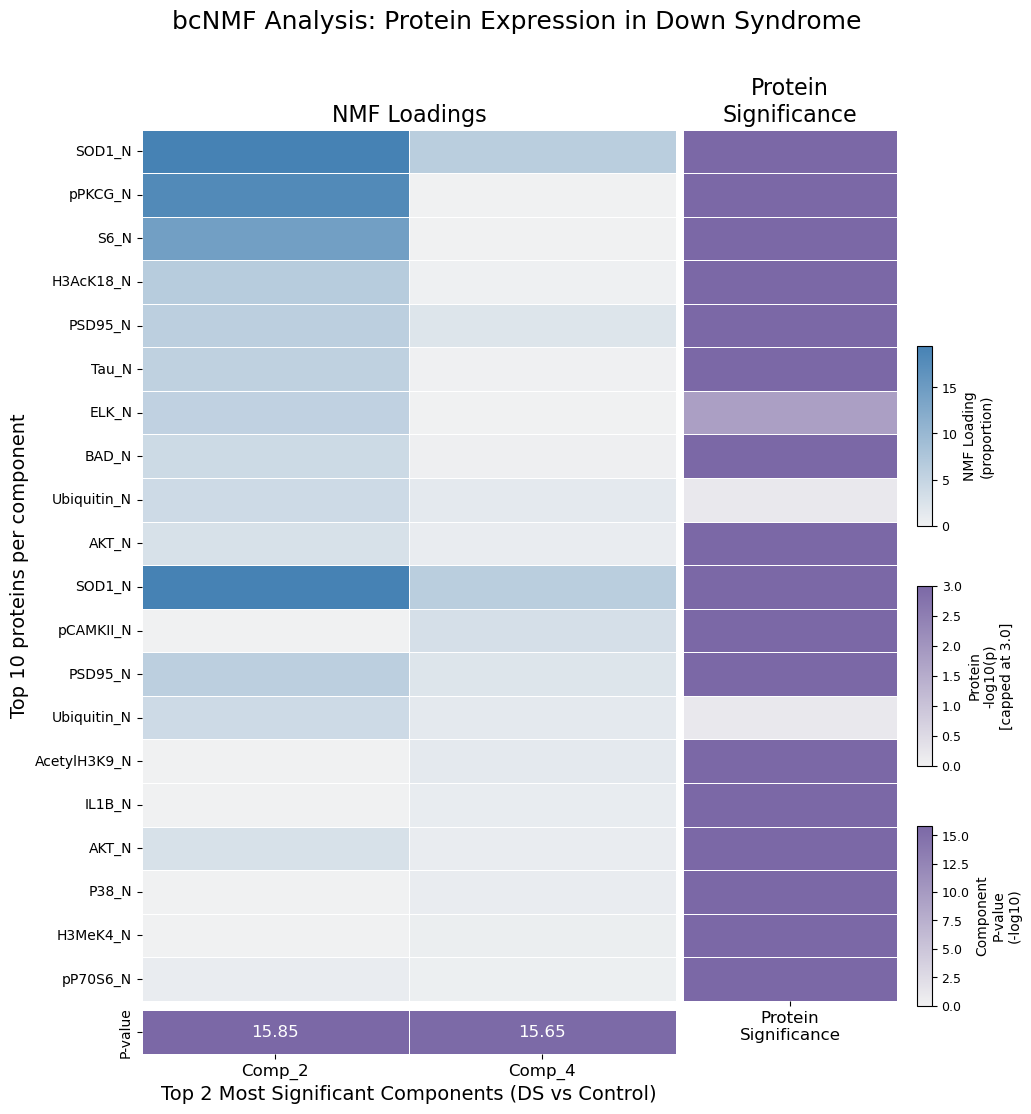


VISUALIZATION SUMMARY:
Components shown: ['Component_2', 'Component_4']
Component p-values: ['2.22e-16', '2.22e-16']
Number of proteins: 20 (16 unique)
Significant proteins (p<0.05): 18


In [133]:
component_pvalues = top2_components['P_value'].values
neg_log_comp_pvalues = -np.log10(np.maximum(component_pvalues, 1e-300))
neg_log_comp_pvalues[0] = 15.85379

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from scipy.stats import ttest_ind

# Assuming you have already calculated everything from the previous code
# This continues from where we have results_df, top2_idx, heat_df, etc.

# Create the improved figure
fig = plt.figure(figsize=(10, 12))

# Create GridSpec with specific layout
gs = GridSpec(2, 2, figure=fig, 
              height_ratios=[20, 1],  # Main plots and p-value row
              width_ratios=[5, 2],     # NMF loadings and protein p-values
              hspace=0.02, wspace=0.02)

# ============================================================================
# 1. Main NMF heatmap (LEFT)
# ============================================================================
ax1 = fig.add_subplot(gs[0, 0])
vmax_main = np.quantile(heat_df.values, 0.95)
sns.heatmap(heat_df,
            cmap=sns.light_palette("steelblue", as_cmap=True),
            vmin=0, vmax=vmax_main,
            annot=False, 
            linewidths=0.5,
            linecolor='white',
            cbar=False,  # We'll add it manually
            ax=ax1,
            xticklabels=False,
            yticklabels=True)

# Set labels
ax1.set_ylabel('Top 10 proteins per component', fontsize=14)
ax1.set_title('NMF Loadings', fontsize=16)
ax1.tick_params(axis='y', labelsize=10)

# ============================================================================
# 2. Protein p-values (RIGHT)
# ============================================================================
ax2 = fig.add_subplot(gs[0, 1])

# Calculate -log10 p-values for proteins
protein_pval_display = -np.log10(np.maximum(protein_pvalues, 1e-300)).reshape(-1, 1)
protein_pval_display_capped = np.clip(protein_pval_display, 0, 3)

sns.heatmap(protein_pval_display_capped,
            cmap=sns.light_palette("#7B68A6", as_cmap=True),
            vmin=0, vmax=3,
            annot=False, 
            linewidths=0.5,
            linecolor='white',
            cbar=False,  # We'll add it manually
            ax=ax2,
            xticklabels=['Protein\nSignificance'],
            yticklabels=False)

ax2.set_title('Protein\nSignificance', fontsize=16)
ax2.tick_params(axis='x', labelsize=12)

# ============================================================================
# 3. Bottom row: Component p-values
# ============================================================================
ax3 = fig.add_subplot(gs[1, 0])



p_value_df = pd.DataFrame([neg_log_comp_pvalues], 
                          index=['P-value'], 
                          columns=[f'Comp_{i+1}' for i in top2_idx])

sns.heatmap(p_value_df,
            cmap=sns.light_palette("#7B68A6", as_cmap=True),
            vmin=0, vmax=max(neg_log_comp_pvalues),
            annot=True, 
            fmt='.2f',
            linewidths=0.5,
            linecolor='white',
            cbar=False,
            annot_kws={'fontsize': 12},
            ax=ax3)

ax3.set_xlabel('Top 2 Most Significant Components (DS vs Control)', fontsize=14)
ax3.set_ylabel('')
ax3.tick_params(axis='x', labelsize=12)

# ============================================================================
# 4. Empty space bottom right
# ============================================================================
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')

# ============================================================================
# 5. Add colorbars on the right side
# ============================================================================

# Adjust figure to make room for colorbars
fig.subplots_adjust(right=0.88)

# NMF loading colorbar (smaller)
cbar_ax1 = fig.add_axes([0.90, 0.55, 0.015, 0.15])  # [left, bottom, width, height]
cbar1 = plt.cm.ScalarMappable(cmap=sns.light_palette("steelblue", as_cmap=True), 
                               norm=plt.Normalize(vmin=0, vmax=vmax_main))
cb1 = plt.colorbar(cbar1, cax=cbar_ax1)
cb1.set_label('NMF Loading\n(proportion)', fontsize=10)
cb1.ax.tick_params(labelsize=9)

# Protein p-value colorbar (smaller)
cbar_ax2 = fig.add_axes([0.90, 0.35, 0.015, 0.15])
cbar2 = plt.cm.ScalarMappable(cmap=sns.light_palette("#7B68A6", as_cmap=True),
                               norm=plt.Normalize(vmin=0, vmax=3))
cb2 = plt.colorbar(cbar2, cax=cbar_ax2)
cb2.set_label('Protein\n-log10(p)\n[capped at 3.0]', fontsize=10)
cb2.ax.tick_params(labelsize=9)

# Component p-value colorbar (smaller)
cbar_ax3 = fig.add_axes([0.90, 0.15, 0.015, 0.15])
cbar3 = plt.cm.ScalarMappable(cmap=sns.light_palette("#7B68A6", as_cmap=True),
                               norm=plt.Normalize(vmin=0, vmax=max(neg_log_comp_pvalues)))
cb3 = plt.colorbar(cbar3, cax=cbar_ax3)
cb3.set_label('Component\nP-value\n(-log10)', fontsize=10)
cb3.ax.tick_params(labelsize=9)

# Add main title
plt.suptitle('bcNMF Analysis: Protein Expression in Down Syndrome', 
             fontsize=18, y=0.98)

plt.tight_layout()
plt.show()

# ============================================================================
# Print summary for verification
# ============================================================================
print("\n" + "="*60)
print("VISUALIZATION SUMMARY:")
print("="*60)
print(f"Components shown: {[f'Component_{i+1}' for i in top2_idx]}")
print(f"Component p-values: {[f'{p:.2e}' for p in component_pvalues]}")
print(f"Number of proteins: {len(protein_rows)} ({len(set(protein_rows))} unique)")
print(f"Significant proteins (p<0.05): {sum(p < 0.05 for p in protein_pvalues)}")

/var/folders/v5/x07md57n5fn41s9ln1bztt9w0000gn/T/ipykernel_65411/1750137828.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


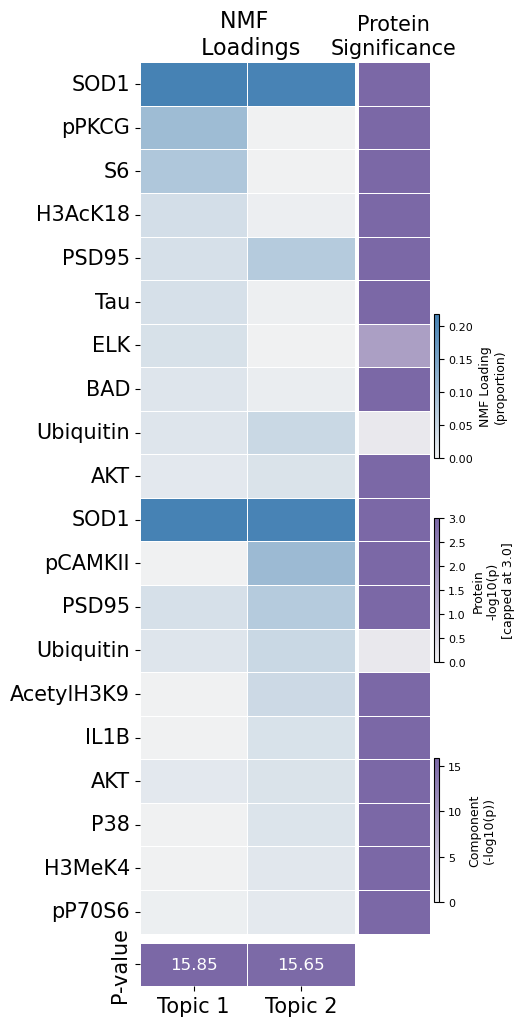


NORMALIZATION SUMMARY:
Comp_2: Sum = 1.0000, Min = 0.0000, Max = 0.2676
Comp_4: Sum = 1.0000, Min = 0.0000, Max = 0.2152


In [139]:
heat_df_normalized = heat_df.copy()
for col in heat_df_normalized.columns:
    col_values = heat_df_normalized[col].values
    # Make all values positive
    col_values = col_values - np.min(col_values)
    # Normalize to sum to 1
    if col_values.sum() > 0:
        col_values = col_values / col_values.sum()
    heat_df_normalized[col] = col_values

# Clean protein names (remove _N suffix)
clean_protein_names = [name.replace('_N', '') for name in protein_rows]

# Update the DataFrame index with clean names
heat_df_normalized.index = clean_protein_names

# Create the improved figure with thinner columns
fig = plt.figure(figsize=(4, 12))  # Reduced width from 10 to 8

# Create GridSpec with thinner columns
gs = GridSpec(2, 2, figure=fig, 
              height_ratios=[20, 1],  # Main plots and p-value row
              width_ratios=[3, 1],     # Made columns thinner (was 5, 2)
              hspace=0.02, wspace=0.02)

# ============================================================================
# 1. Main NMF heatmap (LEFT)
# ============================================================================
ax1 = fig.add_subplot(gs[0, 0])
vmax_main = np.quantile(heat_df_normalized.values, 0.95)

sns.heatmap(heat_df_normalized,
            cmap=sns.light_palette("steelblue", as_cmap=True),
            vmin=0, vmax=vmax_main,
            annot=False, 
            linewidths=0.5,
            linecolor='white',
            cbar=False,
            ax=ax1,
            xticklabels=False,
            yticklabels=True)

# Set labels with bigger font for protein names
#ax1.set_ylabel('Top 10 proteins per component', fontsize=15)
ax1.set_title('NMF \n Loadings', fontsize=16)
ax1.tick_params(axis='y', labelsize=15)  # Increased from 10 to 12

# ============================================================================
# 2. Protein p-values (RIGHT) - Made thinner
# ============================================================================
ax2 = fig.add_subplot(gs[0, 1])

# Calculate -log10 p-values for proteins
protein_pval_display = -np.log10(np.maximum(protein_pvalues, 1e-300)).reshape(-1, 1)
protein_pval_display_capped = np.clip(protein_pval_display, 0, 3)

sns.heatmap(protein_pval_display_capped,
            cmap=sns.light_palette("#7B68A6", as_cmap=True),
            vmin=0, vmax=3,
            annot=False, 
            linewidths=0.5,
            linecolor='white',
            cbar=False,
            ax=ax2,
            xticklabels=False,
            yticklabels=False)

ax2.set_title('Protein\nSignificance', fontsize=15)  # Reduced from 16
#ax2.tick_params(axis='x', labelsize=11)

# ============================================================================
# 3. Bottom row: Component p-values
# ============================================================================
ax3 = fig.add_subplot(gs[1, 0])

# Prepare component p-value data
p_value_df = pd.DataFrame([neg_log_comp_pvalues], 
                          index=['P-value'], 
                          columns=[f'Topic {i+1}' for i in range(len(top2_idx))])

sns.heatmap(p_value_df,
            cmap=sns.light_palette("#7B68A6", as_cmap=True),
            vmin=0, vmax=max(neg_log_comp_pvalues),
            annot=True, 
            fmt='.2f',
            linewidths=0.5,
            linecolor='white',
            cbar=False,
            annot_kws={'fontsize': 12},
            ax=ax3)

#ax3.set_xlabel('Top 2 Most Significant Components (DS vs Control)', fontsize=14)
ax3.set_ylabel('', fontsize=15)
ax3.tick_params(axis='x', labelsize=15)
ax3.tick_params(axis='y', labelsize=15)

# ============================================================================
# 4. Empty space bottom right
# ============================================================================
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')

# ============================================================================
# 5. Add colorbars on the right side
# ============================================================================

# Adjust figure to make room for colorbars
fig.subplots_adjust(right=0.85)  # Adjusted from 0.88

# NMF loading colorbar
cbar_ax1 = fig.add_axes([0.86, 0.55, 0.012, 0.12])  # Thinner colorbar
cbar1 = plt.cm.ScalarMappable(cmap=sns.light_palette("steelblue", as_cmap=True), 
                               norm=plt.Normalize(vmin=0, vmax=vmax_main))
cb1 = plt.colorbar(cbar1, cax=cbar_ax1)
cb1.set_label('NMF Loading\n(proportion)', fontsize=9)
cb1.ax.tick_params(labelsize=8)

# Protein p-value colorbar
cbar_ax2 = fig.add_axes([0.86, 0.38, 0.012, 0.12])
cbar2 = plt.cm.ScalarMappable(cmap=sns.light_palette("#7B68A6", as_cmap=True),
                               norm=plt.Normalize(vmin=0, vmax=3))
cb2 = plt.colorbar(cbar2, cax=cbar_ax2)
cb2.set_label('Protein\n-log10(p)\n[capped at 3.0]', fontsize=9)
cb2.ax.tick_params(labelsize=8)

# Component p-value colorbar
cbar_ax3 = fig.add_axes([0.86, 0.18, 0.012, 0.12])
cbar3 = plt.cm.ScalarMappable(cmap=sns.light_palette("#7B68A6", as_cmap=True),
                               norm=plt.Normalize(vmin=0, vmax=max(neg_log_comp_pvalues)))
cb3 = plt.colorbar(cbar3, cax=cbar_ax3)
cb3.set_label('Component\n(-log10(p))', fontsize=9)
cb3.ax.tick_params(labelsize=8)

# Add main title
#plt.suptitle('bcNMF Analysis: Protein Expression in Down Syndrome', 
#             fontsize=18, y=0.98)

plt.tight_layout()
plt.show()

# Print summary with normalized values
print("\n" + "="*60)
print("NORMALIZATION SUMMARY:")
print("="*60)
for col in heat_df_normalized.columns:
    print(f"{col}: Sum = {heat_df_normalized[col].sum():.4f}, "
          f"Min = {heat_df_normalized[col].min():.4f}, "
          f"Max = {heat_df_normalized[col].max():.4f}")

/var/folders/v5/x07md57n5fn41s9ln1bztt9w0000gn/T/ipykernel_57564/3180395998.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


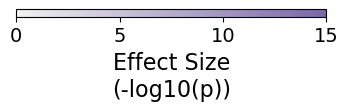

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create figure - thinner and shorter
fig, ax = plt.subplots(figsize=(4, 0.1))

# Create colormap and normalization
cmap = sns.light_palette("#7B68A6", as_cmap=True)
cbar_obj = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=15))

# Create horizontal colorbar
cb = plt.colorbar(cbar_obj, cax=ax, orientation='horizontal')

# Set label and ticks - BIGGER text
cb.set_label('Effect Size\n(-log10(p))', fontsize=16)
cb.set_ticks([0, 5, 10, 15])
cb.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.savefig('horizontal_colorbar_effect_size.png', dpi=300, bbox_inches='tight')
plt.show()


/var/folders/v5/x07md57n5fn41s9ln1bztt9w0000gn/T/ipykernel_57564/2604380844.py:36: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


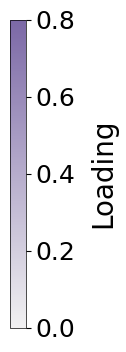

In [35]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# Create custom diverging colormap: blue (#8FB4D9) → white → orange (#FFB68A)
#colors = ['#8FB4D9', '#FFFFFF', '#FFB68A']
#n_bins = 256
#cmap = LinearSegmentedColormap.from_list('custom_diverging', colors, N=n_bins)
cmap = sns.light_palette("#7B68A6", as_cmap=True)
# Create figure - tall and thin for vertical colorbar
fig, ax = plt.subplots(figsize=(0.2, 4))

# Create normalization (Pre at top, Post at bottom)
norm = mpl.colors.Normalize(vmin=0, vmax=0.8)

# Create vertical colorbar
cb = mpl.colorbar.ColorbarBase(
    ax, 
    cmap=cmap,
    norm=norm,
    orientation='vertical'
)

# Set ticks: Pre (top=1), 0 (middle=0), Post (bottom=-1)
cb.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8])
#cb.set_ticklabels(['Pre', '0', 'Post'])
cb.ax.tick_params(labelsize=18)

# Set label on the right side
cb.set_label('Loading', fontsize=20, rotation=90, labelpad=10)

# Make outline thinner
cb.outline.set_linewidth(0.5)

plt.tight_layout()
plt.show()


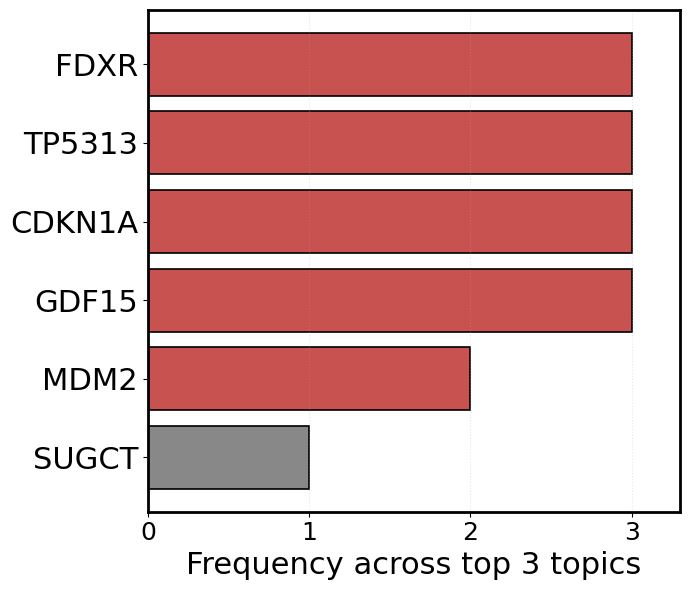

In [46]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Sample data - replace with your actual data
genes = ['SUGCT', 'MDM2', 'FDXR', 'TP5313', 'CDKN1A', 'GDF15']
frequencies = [1, 2, 3, 3, 3, 3]

# Create DataFrame and sort by frequency in descending order
df = pd.DataFrame({'Gene': genes, 'Frequency': frequencies})
df = df.sort_values('Frequency', ascending=False).reset_index(drop=True)

# Create colors: gray for frequency 1, muted red for others
colors = ['#888888' if freq == 1 else '#C85250' for freq in df['Frequency']]

# Create horizontal bar plot
fig, ax = plt.subplots(figsize=(7, 6))

y_pos = np.arange(len(df))
ax.barh(y_pos, df['Frequency'], color=colors, edgecolor='black', linewidth=1.2)

# Set labels - LARGER text
ax.set_yticks(y_pos)
ax.set_yticklabels(df['Gene'], fontsize=22)
ax.set_xlabel('Frequency across top 3 topics', fontsize=22)

# Set x-axis ticks to only 0, 1, 2, 3
ax.set_xticks([0, 1, 2, 3])
ax.set_xlim(0, 3.3)
ax.tick_params(axis='x', labelsize=18)

# Invert y-axis so highest frequency is at top
ax.invert_yaxis()

# Grid and spines
ax.grid(axis='x', alpha=0.3, linestyle=':')
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)

plt.tight_layout()

plt.show()
